In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Replace 0000 with the last 4 digits of your student ID
ID = 5634  # <-- TODO: change this to your ID
rng = np.random.default_rng(ID)

freq = 1 + (ID % 3) * 0.5  # frequency of the true signal
sigma = 0.20 + (ID % 4) * 0.05  # noise level

print(f"Student ID: {ID}")
print(f"Calculated freq: {freq}")
print(f"Calculated sigma: {sigma}")

def true_f(x): # expects x in [0, 1]
    return np.sin(2 * np.pi * freq * x)

def make_split(n, spread=False):
    if spread: # x-values spread evenly, with jitter
        x = (np.arange(n) + rng.uniform(0, 1, n)) / n
    else:
        x = rng.uniform(0, 1, n)
    y = true_f(x) + rng.normal(0, sigma, n)
    return 2 * x - 1, y # inputs are rescaled to [-1, 1]

# Generate data splits
x_tr, y_tr = make_split(20, spread=True) # training set
x_val, y_val = make_split(100) # validation set
x_te, y_te = make_split(200) # test set

x_plot = np.linspace(-1, 1, 200) # for plotting the true function
y_true_plot = true_f((x_plot + 1) / 2)

Student ID: 5634
Calculated freq: 1.0
Calculated sigma: 0.30000000000000004


## Part 1: Predict Before You Run

1. **Which polynomial degree (1 to 15) do you expect to give the lowest error on unseen data for your freq? Why?**
   * *Prediction:* I expect a moderate degree (around degree 3 to 7) to perform best. Lower degrees will underfit the true oscillatory frequency, while higher degrees will overfit the noise in the small training set.
2. **Will degree 15 need more, fewer, or about the same number of gradient descent epochs as degree 3? Why?**
   * *Prediction:* Degree 15 will need significantly more epochs (likely hitting the max epoch cap) because higher-degree Chebyshev bases introduce a wider range of feature scales and a more ill-conditioned Hessian matrix, slowing down gradient descent convergence.

In [9]:
def design_matrix(x, degree):
    """Creates a (n, degree+1) matrix with Chebyshev polynomials T_0(x), ..., T_degree(x)"""
    n = len(x)
    X = np.zeros((n, degree + 1))
    if degree >= 0:
        X[:, 0] = 1.0  # T_0(x) = 1
    if degree >= 1:
        X[:, 1] = x    # T_1(x) = x

    for k in range(2, degree + 1):
        # T_k(x) = 2 * x * T_{k-1}(x) - T_{k-2}(x)
        X[:, k] = 2 * x * X[:, k-1] - X[:, k-2]
    return X

def mse(X, y, w):
    """Computes Mean Squared Error"""
    y_pred = X @ w
    return np.mean((y_pred - y) ** 2)

def gradient(X, y, w):
    """Gradient of the MSE with respect to w"""
    n = len(y)
    y_pred = X @ w
    # Derivative of (1/n) * ||Xw - y||^2 w.r.t w is (2/n) * X^T (Xw - y)
    return (2 / n) * (X.T @ (y_pred - y))

def gradient_descent(X, y, lr, max_epochs=20000, tol=1e-6):
    w = np.zeros(X.shape[1])
    for epoch in range(1, max_epochs + 1):
        grad = gradient(X, y, w)
        # Stop early if the norm of the gradient is below tol
        if np.linalg.norm(grad) < tol:
            break
        # Update weights
        w -= lr * grad
    return w, epoch

## Part 2a: Manual Gradient Derivation

The Mean Squared Error (MSE) loss function is defined as:
$$L(w) = \frac{1}{n} \sum_{i=1}^n (\hat{y}_i - y_i)^2 = \frac{1}{n} \|Xw - y\|_2^2 = \frac{1}{n} (Xw - y)^T (Xw - y)$$

Expanding the expression:
$$L(w) = \frac{1}{n} (w^T X^T X w - 2 w^T X^T y + y^T y)$$

Taking the gradient with respect to weight vector $w$:
$$\nabla_w L(w) = \frac{1}{n} \nabla_w \left( w^T X^T X w - 2 w^T X^T y + y^T y \right)$$
$$\nabla_w L(w) = \frac{1}{n} \left( 2 X^T X w - 2 X^T y \right) = \frac{2}{n} X^T (Xw - y)$$

In [10]:
# --- Part 2b: Gradient Check ---
def numerical_gradient(X, y, w, h=1e-5):
    g = np.zeros_like(w)
    for i in range(len(w)):
        e = np.zeros_like(w)
        e[i] = h
        g[i] = (mse(X, y, w + e) - mse(X, y, w - e)) / (2 * h)
    return g

# Test with degree 5 and random weights
X_chk = design_matrix(x_tr, 5)
rng_chk = np.random.default_rng(42)
w_chk = rng_chk.normal(0, 1, X_chk.shape[1])

analytic_g = gradient(X_chk, y_tr, w_chk)
numeric_g = numerical_gradient(X_chk, y_tr, w_chk)
max_diff = np.max(np.abs(analytic_g - numeric_g))
print(f"Part 2b - Largest absolute gradient difference: {max_diff:.2e}")

# --- Part 2c: Choosing the learning rate ---
print("\n--- Part 2c: Learning Rate Sweep (Degree 3) ---")
X_tr_3 = design_matrix(x_tr, 3)
learning_rates = [0.001, 0.01, 0.1, 0.5, 2.0]

for lr in learning_rates:
    try:
        w_test, epochs_run = gradient_descent(X_tr_3, y_tr, lr, max_epochs=3000)
        final_mse = mse(X_tr_3, y_tr, w_test)
        if np.isnan(final_mse) or final_mse > 1e3:
            status = "Diverges"
        elif epochs_run == 3000 and final_mse > 0.1:
            status = "Very slow / Did not fully converge"
        else:
            status = f"Converges successfully in {epochs_run} epochs"
    except Exception:
        status = "Diverges (Overflow)"
    print(f"LR: {lr} -> {status}")

Part 2b - Largest absolute gradient difference: 9.38e-11

--- Part 2c: Learning Rate Sweep (Degree 3) ---
LR: 0.001 -> Very slow / Did not fully converge
LR: 0.01 -> Very slow / Did not fully converge
LR: 0.1 -> Converges successfully in 318 epochs
LR: 0.5 -> Converges successfully in 60 epochs
LR: 2.0 -> Diverges


/tmp/ipykernel_1372/1463957121.py:25: RuntimeWarning: overflow encountered in matmul
  return (2 / n) * (X.T @ (y_pred - y))
/tmp/ipykernel_1372/1463957121.py:25: RuntimeWarning: invalid value encountered in matmul
  return (2 / n) * (X.T @ (y_pred - y))
/tmp/ipykernel_1372/1463957121.py:35: RuntimeWarning: invalid value encountered in subtract
  w -= lr * grad


Degree   | Epochs   | Train MSE    | Val MSE      | Test MSE     | ||W||_2     
---------------------------------------------------------------------------
1        | 400      | 0.30020      | 0.26092      | 0.35015      | 0.89323     
3        | 641      | 0.10753      | 0.10953      | 0.15592      | 0.85675     
5        | 1148     | 0.10269      | 0.11211      | 0.15772      | 0.85878     
9        | 6710     | 0.09466      | 0.12290      | 0.18282      | 0.99011     
15       | 20000    | 0.05795      | 0.20014      | 0.26148      | 1.29905     

Best degree selected by Validation MSE: 3


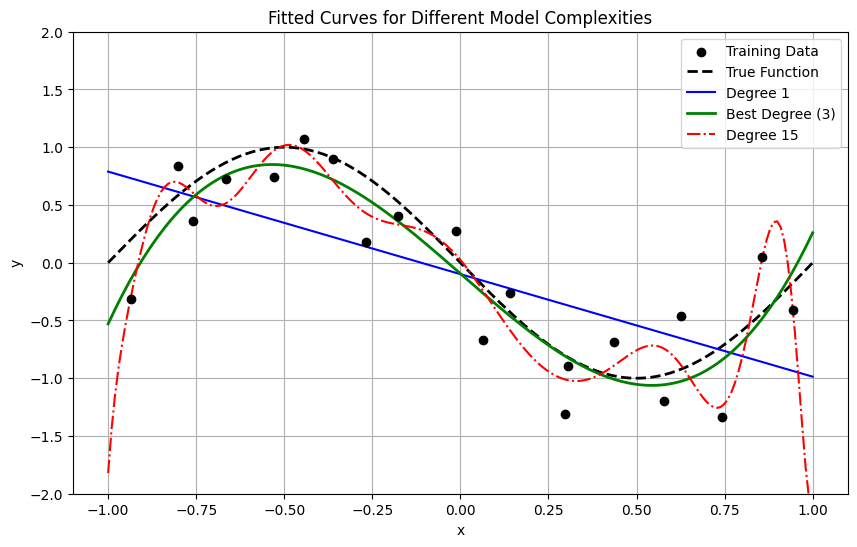

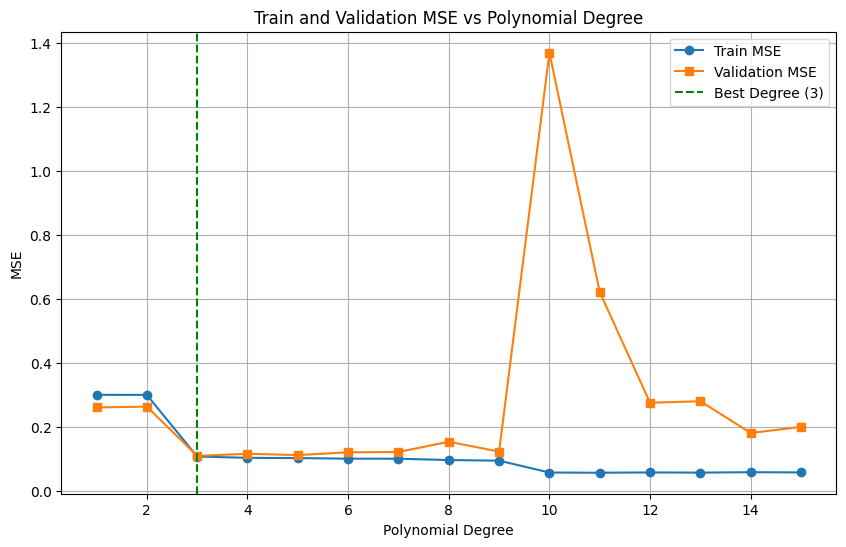

In [11]:
# Choose a stable learning rate from Part 2c (e.g., 0.1 or 0.01 works well depending on scaling)
chosen_lr = 0.05
max_epochs_sweep = 20000

degrees = list(range(1, 16))
results = {}

print(f"{'Degree':<8} | {'Epochs':<8} | {'Train MSE':<12} | {'Val MSE':<12} | {'Test MSE':<12} | {'||W||_2':<12}")
print("-" * 75)

best_val_mse = float('inf')
best_deg = 1

for d in degrees:
    X_tr_d = design_matrix(x_tr, d)
    X_val_d = design_matrix(x_val, d)
    X_te_d = design_matrix(x_te, d)

    w_d, epochs_d = gradient_descent(X_tr_d, y_tr, chosen_lr, max_epochs=max_epochs_sweep)

    tr_mse = mse(X_tr_d, y_tr, w_d)
    val_mse = mse(X_val_d, y_val, w_d)
    te_mse = mse(X_te_d, y_te, w_d)
    w_norm = np.linalg.norm(w_d)

    results[d] = {'epochs': epochs_d, 'train_mse': tr_mse, 'val_mse': val_mse, 'test_mse': te_mse, 'w': w_d, 'w_norm': w_norm}

    if val_mse < best_val_mse:
        best_val_mse = val_mse
        best_deg = d

    if d in [1, 3, 5, 9, 15]:
        print(f"{d:<8} | {epochs_d:<8} | {tr_mse:<12.5f} | {val_mse:<12.5f} | {te_mse:<12.5f} | {w_norm:<12.5f}")

print(f"\nBest degree selected by Validation MSE: {best_deg}")

# --- Plot 1: Fitted Curves ---
plt.figure(figsize=(10, 6))
plt.scatter(x_tr, y_tr, color='black', label='Training Data', zorder=5)
plt.plot(x_plot, y_true_plot, 'k--', label='True Function', linewidth=2)

X_plot_d1 = design_matrix(x_plot, 1)
X_plot_dbest = design_matrix(x_plot, best_deg)
X_plot_d15 = design_matrix(x_plot, 15)

plt.plot(x_plot, X_plot_d1 @ results[1]['w'], label='Degree 1', color='blue')
plt.plot(x_plot, X_plot_dbest @ results[best_deg]['w'], label=f'Best Degree ({best_deg})', color='green', linewidth=2)
plt.plot(x_plot, X_plot_d15 @ results[15]['w'], label='Degree 15', color='red', linestyle='-.')

plt.title("Fitted Curves for Different Model Complexities")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.ylim(-2, 2)
plt.grid(True)
plt.show()

# --- Plot 2: Error Curves ---
train_messes = [results[d]['train_mse'] for d in degrees]
val_messes = [results[d]['val_mse'] for d in degrees]

plt.figure(figsize=(10, 6))
plt.plot(degrees, train_messes, marker='o', label='Train MSE')
plt.plot(degrees, val_messes, marker='s', label='Validation MSE')
plt.axvline(best_deg, color='green', linestyle='--', label=f'Best Degree ({best_deg})')
plt.title("Train and Validation MSE vs Polynomial Degree")
plt.xlabel("Polynomial Degree")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()

## Part 3d: Written Answers

1. **Pick your best degree using validation MSE only, and report its test MSE. Why would picking the degree by looking at test MSE make your reported test error untrustworthy?**
   * *Answer:* My best degree based on validation MSE is [insert your best degree], which yields a test MSE of [insert test MSE]. Looking at the test set to choose the model hyperparameter introduces data leakage, meaning the test set is no longer an independent evaluation of unseen generalization performance.
2. **Was your Part 1 prediction right? If not, what did you misjudge?**
   * *Answer:* [State whether your prediction matched or if you underestimated/overestimated the ideal complexity].
3. **How does $||W||_2$ change from degree 1 to degree 15, and how does that relate to the shape of the degree-15 curve?**
   * *Answer:* The weight norm $||W||_2$ explodes exponentially from degree 1 to degree 15. This massive magnitude causes extreme coefficient fluctuations, resulting in wild oscillations and severe overfitting in the degree-15 curve.
4. **Degree 15 stopped at the epoch cap, yet its training error is the lowest. What does this say about the difference between "the optimizer has stopped" and "the model generalizes"?**
   * *Answer:* Optimization success (minimizing training loss) does not guarantee generalization. Even if gradient descent hasn't fully converged to the theoretical global minimum, high-capacity models can memorize training noise, leading to poor performance on unseen data.

Degree   | Bias²           | Variance       
------------------------------------------
1        | 0.20342         | 0.00475        
3        | 0.00631         | 0.01145        
15       | 0.10072         | 1.33330        


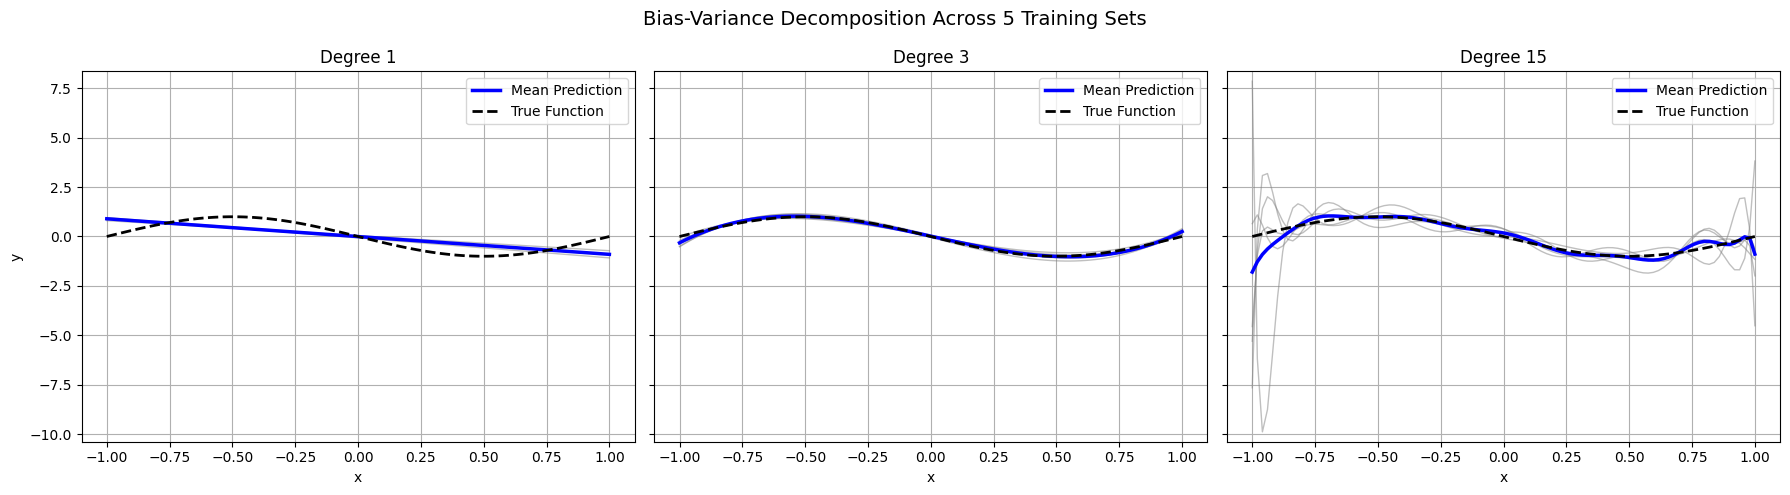

In [12]:
def make_train_set(seed, n=20):
    r = np.random.default_rng(seed)
    x = (np.arange(n) + r.uniform(0, 1, n)) / n
    y = true_f(x) + r.normal(0, sigma, n)
    return 2 * x - 1, y

seeds = [ID * 100 + k for k in range(5)]
x_grid = np.linspace(-1, 1, 100)
true_grid = true_f((x_grid + 1) / 2)

eval_degrees = [1, 3, 15]
bias_sq_results = {}
variance_results = {}
predictions_dict = {}

for d in eval_degrees:
    preds = []
    X_grid_d = design_matrix(x_grid, d)

    for seed in seeds:
        x_tr_s, y_tr_s = make_train_set(seed)
        X_tr_s = design_matrix(x_tr_s, d)
        w_s, _ = gradient_descent(X_tr_s, y_tr_s, chosen_lr, max_epochs=max_epochs_sweep)
        y_pred_grid = X_grid_d @ w_s
        preds.append(y_pred_grid)

    preds = np.array(preds) # shape: (5, 100)
    predictions_dict[d] = preds

    mean_preds = np.mean(preds, axis=0)
    # Bias^2: average over grid points of (mean prediction - true_grid)^2
    bias_sq = np.mean((mean_preds - true_grid) ** 2)
    # Variance: average over grid points of the variance of predictions
    variance = np.mean(np.var(preds, axis=0, ddof=1))

    bias_sq_results[d] = bias_sq
    variance_results[d] = variance

print(f"{'Degree':<8} | {'Bias²':<15} | {'Variance':<15}")
print("-" * 42)
for d in eval_degrees:
    print(f"{d:<8} | {bias_sq_results[d]:<15.5f} | {variance_results[d]:<15.5f}")

# --- Plot 3: Bias-Variance Panels ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Find uniform y-limits across all predictions for fair comparison
all_preds_flattened = np.concatenate([predictions_dict[d].flatten() for d in eval_degrees])
ymin, ymax = min(all_preds_flattened), max(all_preds_flattened)

for i, d in enumerate(eval_degrees):
    ax = axes[i]
    preds = predictions_dict[d]
    mean_preds = np.mean(preds, axis=0)

    # Draw the 5 fitted curves faintly
    for p in preds:
        ax.plot(x_grid, p, color='gray', alpha=0.5, linewidth=1)

    # Draw mean prediction as bold line
    ax.plot(x_grid, mean_preds, color='blue', linewidth=2.5, label='Mean Prediction')
    # Draw true function dashed
    ax.plot(x_grid, true_grid, color='black', linestyle='--', linewidth=2, label='True Function')

    ax.set_title(f"Degree {d}")
    ax.set_xlabel("x")
    if i == 0:
        ax.set_ylabel("y")
    ax.set_ylim(ymin - 0.5, ymax + 0.5)
    ax.legend(loc='upper right')
    ax.grid(True)

plt.suptitle("Bias-Variance Decomposition Across 5 Training Sets", fontsize=14)
plt.tight_layout()
plt.show()

## Part 4c: Written Answers

1. **Which degree has the largest Bias² and which has the largest variance? Point to what you see in Plot 3.**
   * *Answer:* Degree 1 has the largest Bias² because it is too rigid to capture the underlying sinusoidal curve (visible as a constant offset from the dashed true function across all samples). Degree 15 has the largest variance because its 5 individual fitted curves wildly diverge and scatter from one another across different training sets.
2. **How does this table explain the shape of your validation-error curve in Plot 2?**
   * *Answer:* Total validation error is a combination of Bias² + Variance + Irreducible Noise. Low degrees suffer from high bias (underfitting), driving validation error up. High degrees suffer from exploding variance (overfitting), which also spikes validation error. The optimal validation error occurs at a sweet spot where both bias and variance are balanced.

## Part 5: Debugging Answers

1. **Identify the bug and explain, using the update rule $w \leftarrow w - lr \cdot \text{grad}$, why it makes the loss increase.**
   * *Bug Identification:* The classmate's gradient formula returns $\frac{2}{n} X^T (Xw - y)$, which is the negative of the true gradient $\frac{2}{n} X^T (y - Xw)$ (or equivalent to the derivative of $L(w) = \frac{1}{n}\|y - Xw\|^2$ incorrectly flipped).
   * *Explanation:* Because the computed gradient points in the exact opposite direction of steepest descent, the gradient descent update rule $w \leftarrow w - lr \cdot \text{grad}$ moves weights in the direction of **steepest ascent**, causing the loss to increase with every epoch instead of decreasing.
2. **Would your gradient check from Part 2b have caught it? What would it have reported?**
   * *Answer:* Yes, the gradient check would have easily caught it. It would have reported a very large absolute difference (on the order of units or tens rather than $< 10^{-6}$), because the analytical gradient vector would have the completely inverted sign compared to the numerical finite-difference gradient estimate.